This notebook demonstrates a simple beta-binomial model implemented in pangolin, JAGS, PyMC, Pyro, NumPyro, JAGS, and Stan.

In [1]:
import numpy as np
np.random.seed(67)
z_true = 0.7  # True probability of heads
N = 20       # Number of flips

# Generate synthetic observations
x_obs = np.random.binomial(1, z_true, N)
print(f"Generated {x_obs.sum()} heads out of {N} flips ({z_true=})")

Generated 16 heads out of 20 flips (z_true=0.7)


0.7489356 0.08563244


<Axes: ylabel='Count'>

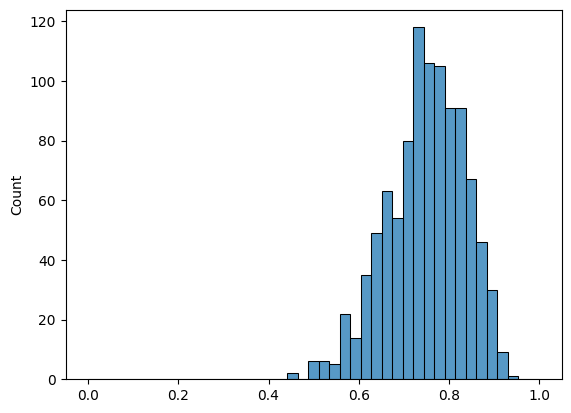

In [2]:
# pangolin

import pangolin
from pangolin import interface as pi

z = pi.beta(2,2)
x = pi.vmap(pi.bernoulli, None, N)(z)
z_samps = pangolin.blackjax.sample(z, x, x_obs)
print(np.mean(z_samps), np.std(z_samps))

import seaborn as sns
sns.histplot(z_samps, binrange=[0,1])

In [3]:
# pymc

import pymc as pm

with pm.Model() as coin_model:
    z = pm.Beta('z', alpha=2, beta=2)
    x = pm.Bernoulli('x', z, observed=x_obs)
    trace = pm.sample(chains=1)
    z_samps = trace.posterior['z'].values
    print(np.mean(z_samps), np.std(z_samps))

/home/j/Projects/pangolin/.venv/lib/python3.13/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [z]


Output()

Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 0 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


0.7505899650918547 0.08869854154228317


In [4]:
# pyro

import pyro
import torch

x_obs_torch = torch.tensor(x_obs, dtype=torch.float)

def model():
    z = pyro.sample('z', pyro.distributions.Beta(2.0, 2.0))
    with pyro.plate('N', N):
        x = pyro.sample('x', pyro.distributions.Bernoulli(z), obs=x_obs_torch)

nuts_kernel = pyro.infer.mcmc.NUTS(model)
mcmc = pyro.infer.mcmc.MCMC(nuts_kernel, warmup_steps=500, num_samples=1000, num_chains=1)
mcmc.run()
z_samps = mcmc.get_samples()['z'].numpy()
print(np.mean(z_samps), np.std(z_samps))


Sample: 100%|██████████| 1500/1500 [00:02, 583.21it/s, step size=1.19e+00, acc. prob=0.900]

0.7544593 0.08357391


In [5]:
# numpyro

import numpyro
import jax
import jax.numpy as jnp

def model():
    z = numpyro.sample('z', numpyro.distributions.Beta(2.0, 2.0))
    with numpyro.plate('data', N):
        x = numpyro.sample('x', numpyro.distributions.Bernoulli(z), obs=x_obs)

nuts_kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=1)
mcmc.run(jax.random.PRNGKey(42))
z_samps = mcmc.get_samples()['z']
print(np.mean(z_samps), np.std(z_samps))

sample: 100%|██████████| 1500/1500 [00:01<00:00, 963.39it/s, 1 steps of size 9.71e-01. acc. prob=0.92] 


0.7403539 0.09192041


In [6]:
# pyjags

import pyjags

model_code = """
model {
  z ~ dbeta(2, 2)
  for (i in 1:N) {
    x[i] ~ dbern(z)
  }
}
"""

model = pyjags.Model(
    code=model_code,
    data={'N': N, 'x': x_obs.tolist()},
    chains=1,
    adapt=500
)

samples = model.sample(1000, ['z'])
z_samps = samples['z'].flatten()
print(np.mean(z_samps), np.std(z_samps))

sampling: iterations 1000 of 1000, elapsed 0:00:00, remaining 0:00:00
0.7486672794346761 0.09015192800563612


In [7]:
# stan

import cmdstanpy
import tempfile
from pathlib import Path

stan_code = """
data {
  int<lower=0> N;
  array[N] int<lower=0, upper=1> x;
}
parameters {
  real<lower=0, upper=1> z;
}
model {
  z ~ beta(2, 2);
  x ~ bernoulli(z);
}
"""

with tempfile.TemporaryDirectory() as tmpdir:
    stan_file = Path(tmpdir) / "coin_model.stan"
    stan_file.write_text(stan_code)

    model = cmdstanpy.CmdStanModel(stan_file=str(stan_file))

    fit = model.sample(
        data={'N': N, 'x': x_obs},
        chains=1,
        iter_warmup=500,
        iter_sampling=1000,
        seed=42
    )
    z_samps = fit.stan_variable('z')
    print(np.mean(z_samps), np.std(z_samps))

07:51:27 - cmdstanpy - INFO - compiling stan file /tmp/tmp3nypu9i6/coin_model.stan to exe file /tmp/tmp3nypu9i6/coin_model
07:51:34 - cmdstanpy - INFO - compiled model executable: /tmp/tmp3nypu9i6/coin_model
07:51:34 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

07:51:34 - cmdstanpy - INFO - CmdStan done processing.



0.75034533117 0.08958131402409994
